# Solar Illumination Planning

**Purpose:** Solar geometry determines when sufficient illumination is available for airborne remote sensing, affects data quality through shadow and glint effects, and constrains the daily time window for data collection. This notebook demonstrates how to use HyPlan's `sun` module to compute solar positions, find usable collection windows, and plan campaigns around illumination constraints.

| | |
|---|---|
| **Audience** | Beginner |
| **Runtime** | < 1 minute |
| **Requires internet** | No |
| **Credentials required** | None |
| **Optional dependencies** | None |
| **Uses example data** | No (coordinates are specified inline) |

**What You Will Learn:**
- How solar elevation and azimuth affect remote sensing data quality
- How to compute solar positions at any location and time
- How to find daily collection windows based on solar elevation thresholds
- How to visualize solar tracks with polar sky plots
- How seasonal and latitudinal variation impacts campaign scheduling
- How to use automatic timezone lookup for DST-correct planning

In [1]:
from datetime import datetime, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from hyplan.sun import (
    solar_azimuth,
    solar_position_increments,
    solar_threshold_times,
    plot_solar_positions,
)

## 1. Solar Azimuth at a Specific Time

**Why this matters:** The sun's azimuth (compass bearing) determines the direction of shadows on the ground and controls sun glint on water surfaces. For imaging spectrometers, knowing the solar azimuth helps avoid flight headings that place glint in the sensor's field of view. For terrain studies, it determines which slopes are illuminated and which are in shadow.

`solar_azimuth()` returns the sun's compass bearing (degrees clockwise from north) at a given location and UTC datetime.

In [2]:
# Monterey Bay, California
lat, lon = 36.8, -121.9

# Solar azimuth at noon local time (UTC-7) on July 15
dt = datetime(2025, 7, 15, 19, 0, 0)  # 12:00 PM Pacific = 19:00 UTC
az = solar_azimuth(lat, lon, dt)
print(f"Solar azimuth at {dt} UTC: {az:.2f} deg")

# Track azimuth across several hours
print("\nHourly solar azimuths:")
for hour_utc in range(16, 24):
    dt_h = datetime(2025, 7, 15, hour_utc, 0, 0)
    az_h = solar_azimuth(lat, lon, dt_h)
    local_hour = hour_utc - 7
    print(f"  {local_hour:2d}:00 local ({hour_utc:2d}:00 UTC) -> azimuth = {az_h:.1f} deg")

Solar azimuth at 2025-07-15 19:00:00 UTC: 128.88 deg

Hourly solar azimuths:
   9:00 local (16:00 UTC) -> azimuth = 87.1 deg
  10:00 local (17:00 UTC) -> azimuth = 96.4 deg
  11:00 local (18:00 UTC) -> azimuth = 108.7 deg
  12:00 local (19:00 UTC) -> azimuth = 128.9 deg
  13:00 local (20:00 UTC) -> azimuth = 168.2 deg
  14:00 local (21:00 UTC) -> azimuth = 216.3 deg
  15:00 local (22:00 UTC) -> azimuth = 243.6 deg
  16:00 local (23:00 UTC) -> azimuth = 258.5 deg


In [ ]:
**Interpreting the output:** At solar noon (12:00 local), the azimuth is approximately 129 degrees (south-southeast) because Monterey Bay is at 36.8 N latitude in midsummer -- the sun culminates south of directly overhead. The azimuth sweeps from east (~87 degrees at 9 AM) through south to west (~259 degrees at 4 PM). If you are flying east-west lines over water, morning flights (azimuth near 90 degrees) would place sun glint directly ahead of an eastbound aircraft, which may be undesirable.

## 2. Solar Position Throughout the Day

**The problem:** You need to know not just where the sun is at one moment, but the full arc of the sun across the sky to determine when illumination conditions are adequate for data collection. Most imaging spectrometers require a minimum solar elevation (typically 30-40 degrees) to ensure sufficient signal-to-noise and avoid long shadows that obscure the target.

`solar_position_increments()` returns a table of solar azimuth and elevation at regular intervals, filtered to times when the elevation exceeds a minimum threshold. This is the primary tool for understanding the daily solar geometry at a site.

In [3]:
# Solar positions on July 15 when elevation > 30 deg (good illumination)
df_positions = solar_position_increments(
    lat, lon,
    date="2025-07-15",
    min_elevation=30,
    timezone_offset=-7,   # Pacific time
    increment="10min",    # 10-minute intervals (default)
)
print(f"Time window with solar elevation > 30 deg: {len(df_positions)} intervals")
print(f"First: {df_positions.iloc[0]['Time']}, Last: {df_positions.iloc[-1]['Time']}")
df_positions

Time window with solar elevation > 30 deg: 54 intervals
First: 17:00:00, Last: 16:50:00


,Time,Azimuth,Elevation
0,17:00:00,269.034774,39.026393
1,17:10:00,270.537034,37.024164
2,17:20:00,272.001232,35.022414
3,17:30:00,273.433628,33.022424
4,17:40:00,274.839800,31.025396
5,08:50:00,85.649606,31.526252
6,09:00:00,87.067275,33.523316
7,09:10:00,88.512956,35.522936
8,09:20:00,89.992431,37.523878
9,09:30:00,91.512205,39.524820


**Interpreting the output:** With a 30-degree minimum elevation threshold, there are 54 ten-minute intervals of usable illumination on July 15 at Monterey Bay -- roughly 9 hours. The table shows that elevation peaks near 74.6 degrees around 13:10 local time. For a typical imaging spectrometer mission requiring 35-55 degree solar elevation, the usable window would be narrower. The morning and afternoon segments of the window are separated by the high-sun midday period, which may or may not be desirable depending on the science objectives.

## 3. Polar Plot of Solar Positions

**Mental model:** A polar sky plot shows the sun's path as seen by an observer looking straight up. The center of the plot is directly overhead (zenith), the outer edge is the horizon, the angular axis is compass direction (azimuth), and the radial axis is zenith angle (90 minus elevation). This provides an intuitive view of where the sun is in the sky at each time, which is useful for understanding shadow directions and glint geometry.

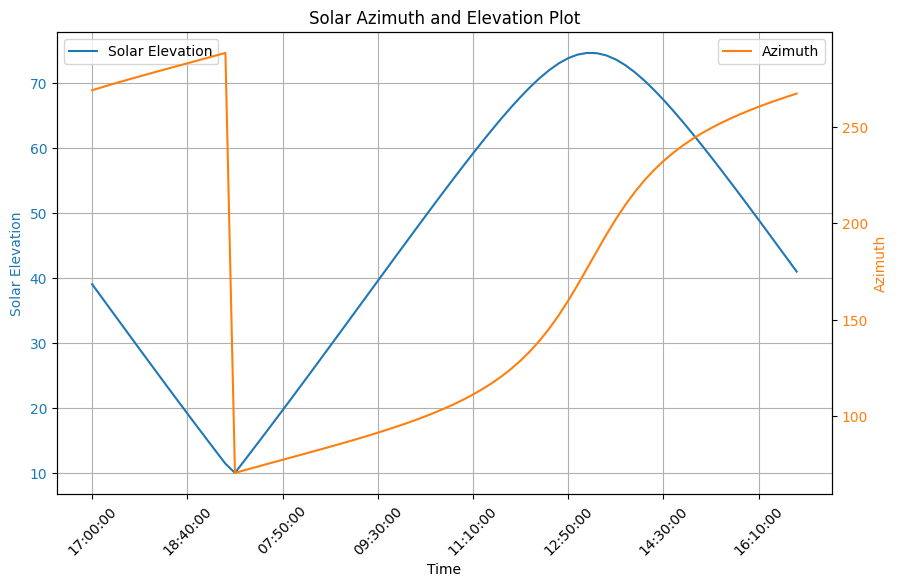

In [4]:
# Use a lower elevation threshold to see more of the day
df_full_day = solar_position_increments(
    lat, lon,
    date="2025-07-15",
    min_elevation=10,
    timezone_offset=-7,
)
plot_solar_positions(df_full_day)

**Interpreting the plot:** The sun rises in the northeast, arcs high across the southern sky (small zenith angle = near center), and sets in the northwest. At this mid-latitude summer location, the sun reaches within about 15 degrees of directly overhead. The asymmetry of the arc -- it does not pass through the exact center -- reflects the site's distance from the tropics.

## 4. Solar Threshold Times

**The problem:** Mission planners need to know the exact clock times when solar elevation crosses specific thresholds -- for example, "at what time does the sun rise above 35 degrees?" and "when does it drop back below?" These times define the daily data-collection window.

`solar_threshold_times()` finds the exact times when the solar elevation crosses specified thresholds over a date range. For example, many imaging spectrometers require solar elevation between 35 and 55 degrees. The function returns the rise and set times for each threshold on each day.

In [5]:
# Daily threshold times for a two-week campaign window
# Thresholds: 35 deg (minimum for good data) and 55 deg (avoid steep sun angles)
df_thresholds = solar_threshold_times(
    lat, lon,
    start_date="2025-07-01",
    end_date="2025-07-14",
    thresholds=[35, 55],
    timezone_offset=-7,  # Pacific time
)
print("Daily solar threshold crossing times (local time):")
df_thresholds

Daily solar threshold crossing times (local time):


,Date,Rise_35,Rise_55,Set_55,Set_35
0,2025-07-01,09:02:00,10:42:00,15:41:00,17:22:00
1,2025-07-02,09:02:00,10:43:00,15:41:00,17:21:00
2,2025-07-03,09:02:00,10:43:00,15:41:00,17:21:00
3,2025-07-04,09:03:00,10:43:00,15:41:00,17:21:00
4,2025-07-05,09:03:00,10:44:00,15:41:00,17:21:00
5,2025-07-06,09:04:00,10:44:00,15:41:00,17:21:00
6,2025-07-07,09:04:00,10:45:00,15:41:00,17:21:00
7,2025-07-08,09:05:00,10:45:00,15:40:00,17:21:00
8,2025-07-09,09:05:00,10:46:00,15:40:00,17:21:00
9,2025-07-10,09:05:00,10:46:00,15:40:00,17:21:00


**Interpreting the output:** For this two-week July window at Monterey Bay, the sun rises above 35 degrees around 9:02-9:07 AM local time and sets below 35 degrees around 5:00-5:22 PM, giving roughly 8 hours of usable illumination per day. The 55-degree threshold narrows this to about 5 hours (10:42 AM to 3:41 PM). These times shift only slightly over two weeks in midsummer, but would vary much more across a month in spring or fall. For mission scheduling, the rise/set times tell you the earliest takeoff and latest landing times that keep data collection within the illumination window.

### Automatic timezone lookup

Hard-coding `timezone_offset=-7` is fragile: it's wrong by an hour after a DST transition, and you have to look up the offset for every new site. `get_timezone(lat, lon)` returns the IANA timezone name, which you can pass straight into `solar_threshold_times` and `solar_position_increments` via the `timezone=` keyword. The IANA path is DST-aware, so a campaign that spans the spring-forward boundary will get the right wall-clock times automatically.

In [6]:
from hyplan.geometry import get_timezone

# Look up the IANA timezone for the Monterey site (works for any lat/lon)
tz_name = get_timezone(lat, lon)
print(f"Timezone for ({lat}, {lon}): {tz_name}")

# Re-run the threshold-times query using the IANA zone instead of -7.
# The result is identical here (we're outside DST transitions) but the
# call is portable across sites and DST-correct year-round.
df_thresholds_iana = solar_threshold_times(
    lat, lon,
    start_date="2025-07-01",
    end_date="2025-07-14",
    thresholds=[35, 55],
    timezone=tz_name,
)
df_thresholds_iana.head()

Timezone for (36.8, -121.9): America/Los_Angeles


,Date,Rise_35,Rise_55,Set_55,Set_35
0,2025-07-01,09:02:00,10:42:00,15:41:00,17:22:00
1,2025-07-02,09:02:00,10:43:00,15:41:00,17:21:00
2,2025-07-03,09:02:00,10:43:00,15:41:00,17:21:00
3,2025-07-04,09:03:00,10:43:00,15:41:00,17:21:00
4,2025-07-05,09:03:00,10:44:00,15:41:00,17:21:00


## 5. Visualizing Data-Collection Windows

**The problem:** A table of rise/set times is useful, but a visualization makes it easier to spot trends -- are windows getting shorter? Is there enough time for multiple sorties per day? The plots below show both the window duration and the bounding times for each day.

/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_44424/1206065912.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_thresholds[set_col]) - pd.to_datetime(df_thresholds[rise_col])
/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_44424/1206065912.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_thresholds[set_col]) - pd.to_datetime(df_thresholds[rise_col])
/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_44424/1206065912.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_thresholds[rise

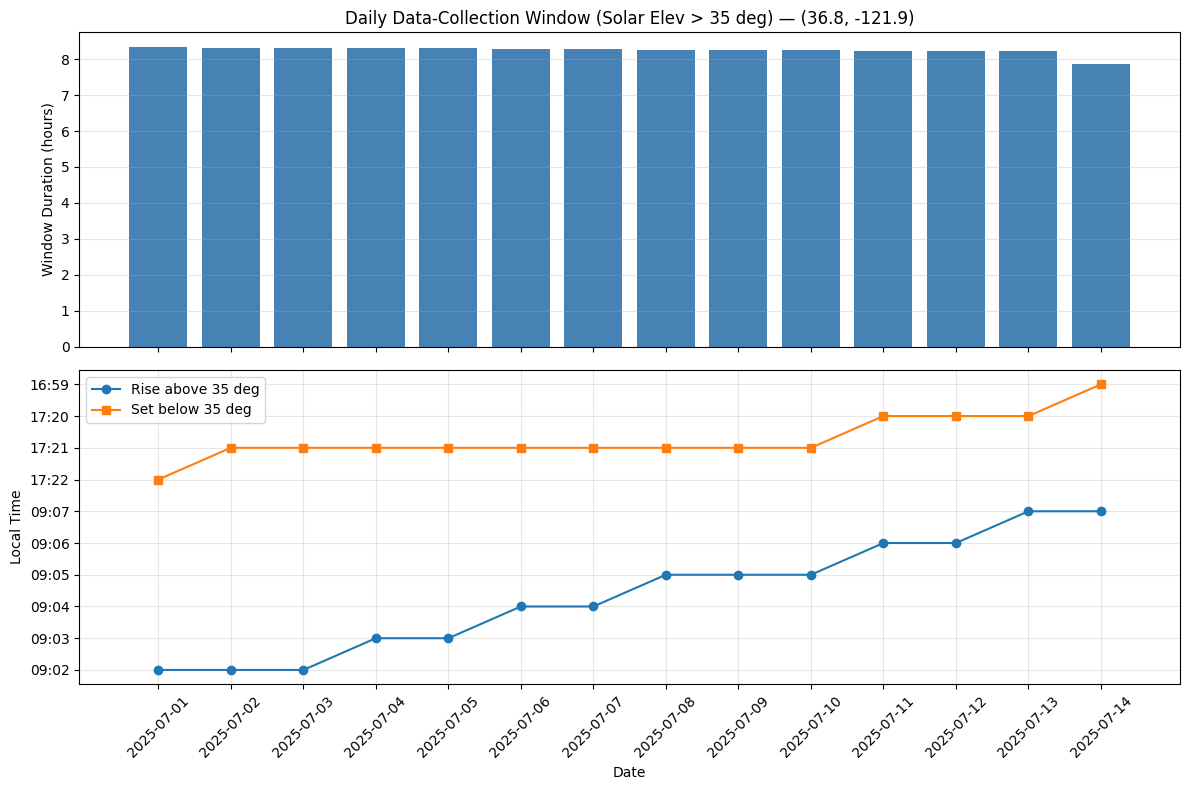

In [7]:
# Compute the data-collection window width using the 35-degree threshold
# The window is from Rise_35 to Set_35
rise_col = [c for c in df_thresholds.columns if c.startswith("Rise_35")][0]
set_col = [c for c in df_thresholds.columns if c.startswith("Set_35")][0]

df_thresholds["Window_hours"] = (
    pd.to_datetime(df_thresholds[set_col]) - pd.to_datetime(df_thresholds[rise_col])
).dt.total_seconds() / 3600

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Window duration per day
axes[0].bar(df_thresholds["Date"].astype(str), df_thresholds["Window_hours"], color="steelblue")
axes[0].set_ylabel("Window Duration (hours)")
axes[0].set_title(f"Daily Data-Collection Window (Solar Elev > 35 deg) — ({lat}, {lon})")
axes[0].grid(True, axis="y", alpha=0.3)

# Rise and set times
axes[1].plot(df_thresholds["Date"].astype(str),
             pd.to_datetime(df_thresholds[rise_col]).dt.strftime("%H:%M"),
             "o-", label="Rise above 35 deg")
axes[1].plot(df_thresholds["Date"].astype(str),
             pd.to_datetime(df_thresholds[set_col]).dt.strftime("%H:%M"),
             "s-", label="Set below 35 deg")
axes[1].set_ylabel("Local Time")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpreting the plot:** The top panel shows that the data-collection window (solar elevation above 35 degrees) is consistently around 8.3 hours per day during early-to-mid July at Monterey Bay, with a slight decrease over the two weeks as the sun begins its post-solstice southward migration. The bottom panel shows the rise and set times are nearly constant. This stability is good news for campaign logistics: takeoff times and return times are predictable day to day.

## 6. Comparing Sites and Seasons

**Why this matters:** Solar geometry varies dramatically with latitude and time of year. A campaign that works well in midsummer California may have an impossibly short window in winter or at high latitudes. Comparing sites and seasons helps mission planners choose optimal campaign timing and identify geographic constraints.

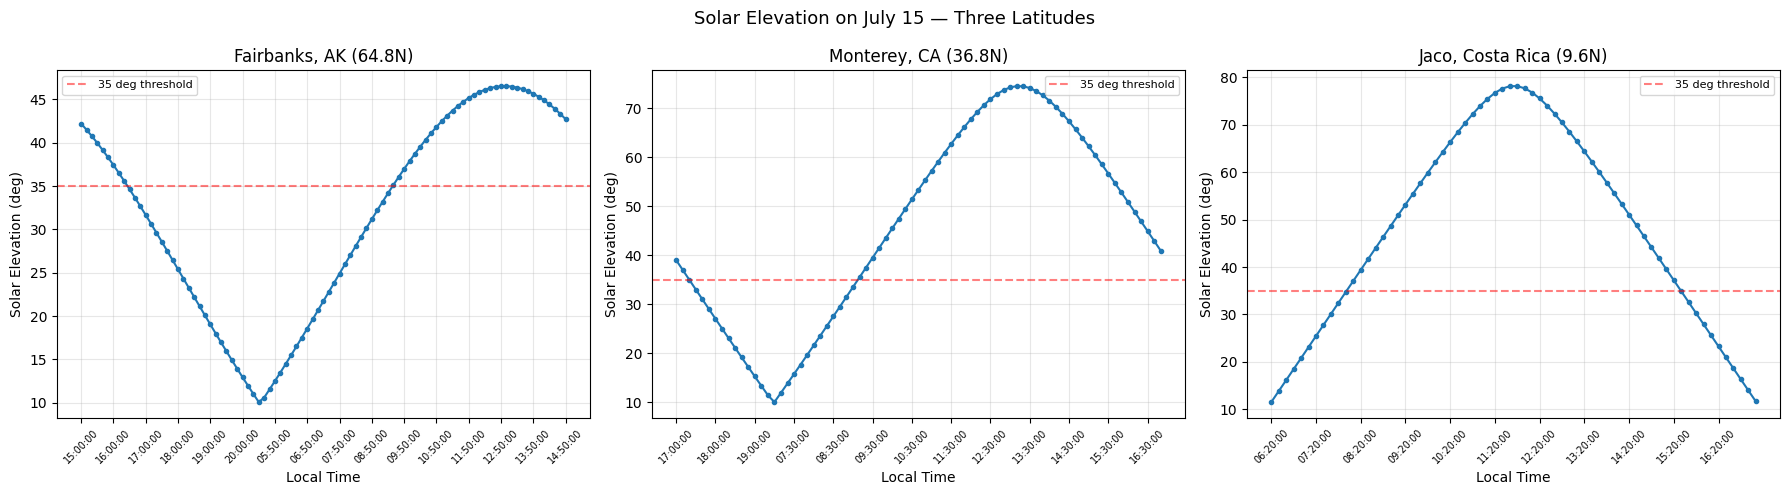

In [8]:
# Compare solar tracks at three different latitudes on the same day
sites = [
    ("Fairbanks, AK", 64.84, -147.72, -9),
    ("Monterey, CA", 36.8, -121.9, -7),
    ("Jaco, Costa Rica", 9.62, -84.82, -6),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, s_lat, s_lon, tz) in zip(axes, sites):
    df = solar_position_increments(s_lat, s_lon, "2025-07-15", min_elevation=10,
                                   timezone_offset=tz, increment="10min")
    ax.plot(df["Time"], df["Elevation"], "o-", markersize=3)
    ax.axhline(y=35, color="red", linestyle="--", alpha=0.5, label="35 deg threshold")
    ax.set_title(f"{name} ({s_lat:.1f}N)")
    ax.set_xlabel("Local Time")
    ax.set_ylabel("Solar Elevation (deg)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    # Show every 6th tick to avoid crowding
    ticks = ax.get_xticks()
    ax.set_xticks(ticks[::6])
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)

plt.suptitle("Solar Elevation on July 15 — Three Latitudes", fontsize=13)
plt.tight_layout()
plt.show()

**Interpreting the plot:** At Fairbanks (65 N), the sun barely exceeds 35 degrees even in midsummer, giving a narrow collection window. At Monterey (37 N), there is a broad window of roughly 8 hours above the threshold. At Jaco, Costa Rica (10 N), the sun passes almost directly overhead, so the 35-degree threshold is met for most of the daylight hours. This comparison shows why high-latitude campaigns are severely time-constrained and why tropical campaigns have more scheduling flexibility.

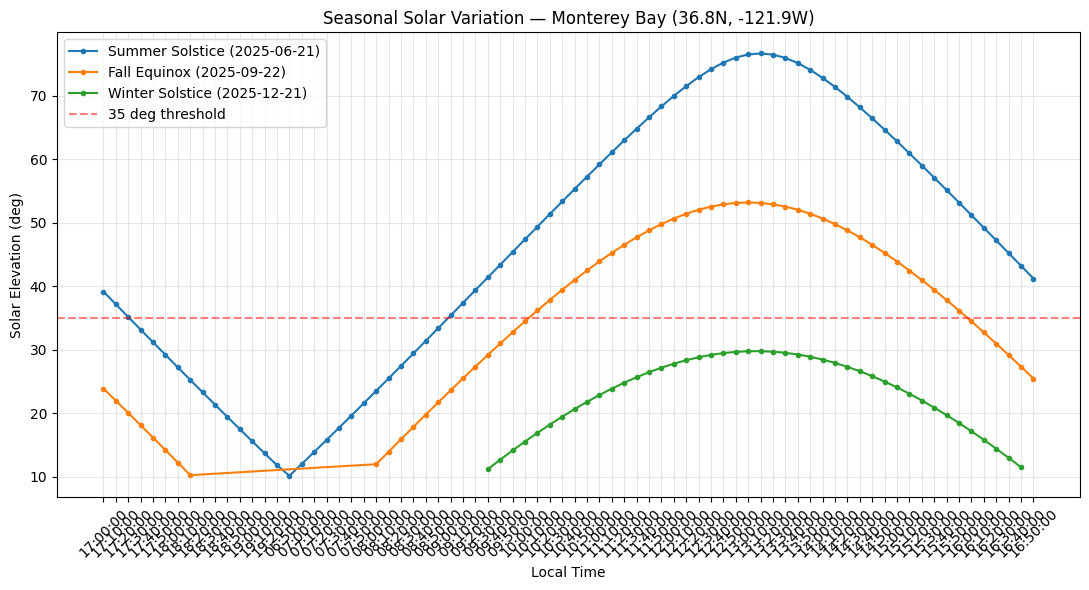

In [9]:
# Compare seasonal variation at Monterey: summer vs winter solstice vs equinox
dates = [
    ("Summer Solstice", "2025-06-21"),
    ("Fall Equinox", "2025-09-22"),
    ("Winter Solstice", "2025-12-21"),
]

fig, ax = plt.subplots(figsize=(11, 6))

for label, date in dates:
    df = solar_position_increments(lat, lon, date, min_elevation=10,
                                   timezone_offset=-7, increment="10min")
    ax.plot(df["Time"], df["Elevation"], "o-", markersize=3, label=f"{label} ({date})")

ax.axhline(y=35, color="red", linestyle="--", alpha=0.5, label="35 deg threshold")
ax.set_xlabel("Local Time")
ax.set_ylabel("Solar Elevation (deg)")
ax.set_title(f"Seasonal Solar Variation — Monterey Bay ({lat}N, {lon}W)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpreting the plot:** At Monterey Bay, the summer solstice offers a broad, high-elevation arc with approximately 8 hours above 35 degrees. By the fall equinox, the peak elevation drops and the window shrinks to about 6 hours. At the winter solstice, the sun barely reaches 35 degrees, leaving almost no usable collection time. This seasonal compression is the primary reason California airborne campaigns are typically scheduled between April and October.

## 7. Multi-Day Campaign Planning

**The problem:** For a multi-week deployment, you need to know the collection window for every day. This helps with scheduling flights, rest days, logistics, and coordinating with other constraints (cloud cover, crew availability). Generating a threshold table for the entire campaign period provides a complete reference.

In [10]:
# Costa Rica coastal campaign — Feb 1 to Mar 7
# Thresholds: 35 deg (minimum) and 55 deg (maximum for avoiding steep angles)
cr_lat, cr_lon = 9.615, -84.82

df_campaign = solar_threshold_times(
    cr_lat, cr_lon,
    start_date="2025-02-01",
    end_date="2025-03-07",
    thresholds=[35, 55],
    timezone_offset=-6,  # Costa Rica time (CST)
)
print(f"Campaign: {len(df_campaign)} days")
print(f"Columns: {list(df_campaign.columns)}")
df_campaign.head(10)

Campaign: 35 days
Columns: ['Date', 'Rise_35', 'Rise_55', 'Set_55', 'Set_35']


,Date,Rise_35,Rise_55,Set_55,Set_35
0,2025-02-01,08:38:00,10:21:00,13:25:00,15:07:00
1,2025-02-02,08:38:00,10:20:00,13:26:00,15:08:00
2,2025-02-03,08:38:00,10:19:00,13:28:00,15:09:00
3,2025-02-04,08:37:00,10:17:00,13:29:00,15:10:00
4,2025-02-05,08:37:00,10:16:00,13:31:00,15:10:00
5,2025-02-06,08:36:00,10:15:00,13:32:00,15:11:00
6,2025-02-07,08:36:00,10:14:00,13:33:00,15:11:00
7,2025-02-08,08:35:00,10:13:00,13:34:00,15:12:00
8,2025-02-09,08:34:00,10:11:00,13:36:00,15:13:00
9,2025-02-10,08:34:00,10:10:00,13:37:00,15:13:00


**Interpreting the output:** For this Costa Rica coastal campaign (Feb 1 to Mar 7), the 35-degree collection window runs from about 8:34 AM to 3:13 PM local time -- roughly 6.5 hours per day. Over the 35-day period, the window gradually widens as the sun moves northward toward the equinox. The 55-degree threshold times show an inner window of about 3 hours centered on solar noon. These windows are shorter than a midsummer California campaign because the site is at low latitude and the dates are near the winter solstice for that latitude.

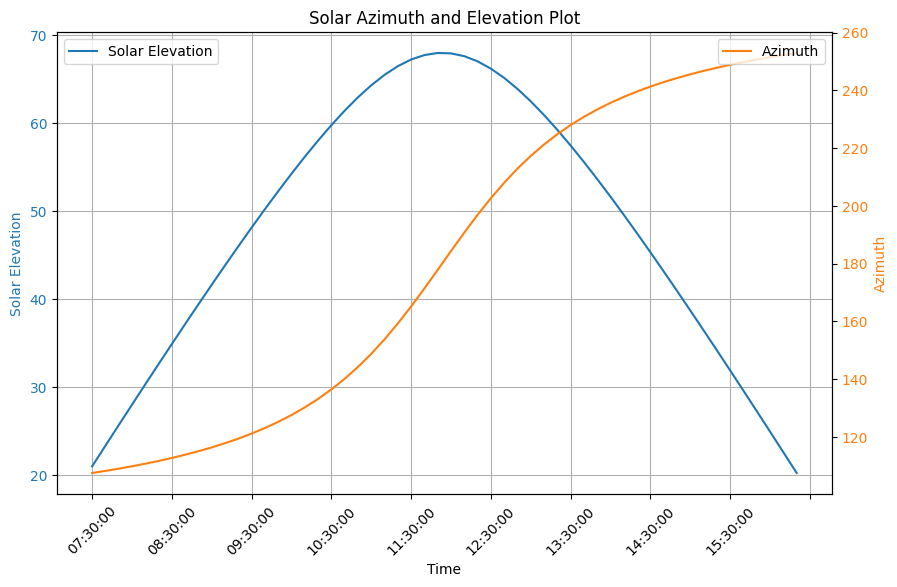

In [11]:
# Polar plot for a specific campaign day
df_cr_day = solar_position_increments(
    cr_lat, cr_lon,
    date="2025-02-15",
    min_elevation=20,
    timezone_offset=-6,
)
plot_solar_positions(df_cr_day)

## Operational Takeaways

- **Solar elevation thresholds define your daily collection window.** Most imaging spectrometers require 35-55 degree solar elevation. Outside this range, shadows are too long or signal-to-noise is too low for reliable data.
- **Latitude dominates window duration.** High-latitude sites (above 50 N) may have windows of only 2-4 hours in shoulder seasons, while tropical sites have 6-8 hours year-round.
- **Season matters more than you think.** At mid-latitudes, the collection window can shrink from 8 hours in summer to nearly zero in winter. Plan campaigns accordingly.
- **Use automatic timezone lookup** (`get_timezone`) instead of hard-coding UTC offsets. This avoids errors at DST transitions and makes plans portable across sites.
- **Solar azimuth constrains flight heading for water targets.** Avoid headings that place sun glint in the sensor field of view -- consult the azimuth tables or polar plots to identify problematic time/heading combinations.
- **Combine solar windows with other constraints.** The collection window from this notebook should be intersected with cloud cover forecasts (see `cloud_analysis.ipynb`) and wind conditions (see `winds.ipynb`) to determine actually flyable time slots.

## API Summary

| Function | Purpose |
|----------|---------|
| `solar_azimuth(lat, lon, dt)` | Sun's compass bearing at a specific UTC time |
| `solar_position_increments(lat, lon, date, min_elevation, ...)` | Table of azimuth/elevation at regular intervals |
| `plot_solar_positions(df)` | Polar sky plot of the sun's track |
| `solar_threshold_times(lat, lon, start, end, thresholds, ...)` | Daily times when elevation crosses thresholds |

**Key parameters:**
- `timezone_offset` or `timezone` -- Convert UTC results to local time for easier interpretation
- `min_elevation` -- Filter to times with adequate illumination
- `increment` -- Time step for position sampling (default "10min")
- `thresholds` -- List of elevation angles to find crossing times for